<a href="https://colab.research.google.com/github/MageroOduor/ML/blob/main/Practical_Assignment_%E2%80%93_Clustering_with_the_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1: Load the Dataset**

In [14]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Show first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


**Task 2: Explore the Data**


Shape of dataset: (150, 6)
Column names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species', 'species_name']


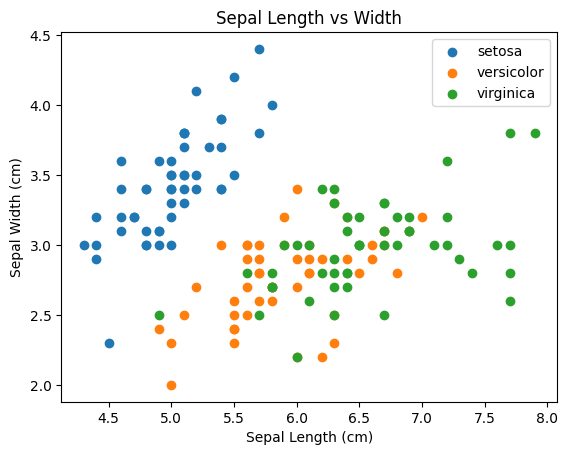

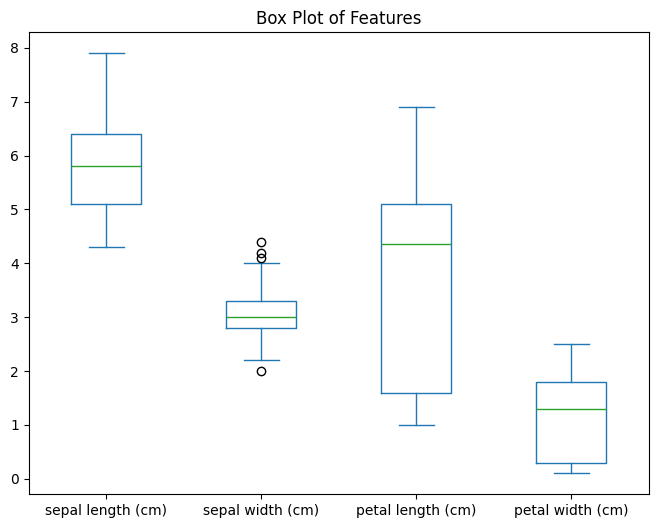

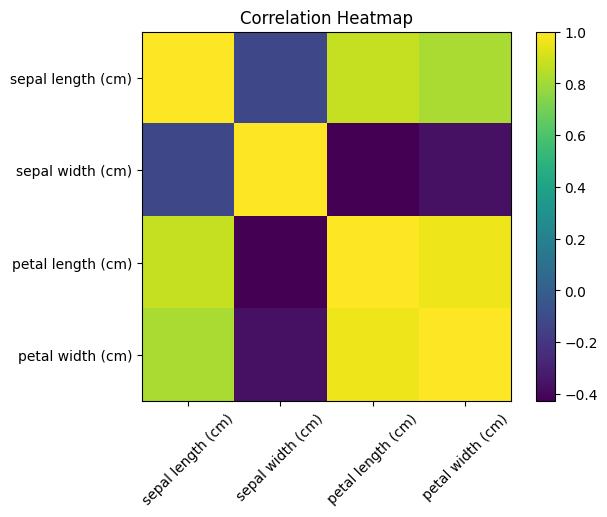

In [15]:
from sklearn.datasets import load_iris

# Re-load iris data to get the target if 'species' column is not present
if 'species' not in df.columns:
    iris_data = load_iris()
    df['species'] = iris_data.target
    df['species_name'] = df['species'].map(lambda x: iris_data.target_names[x])

print("\nShape of dataset:", df.shape)
print("Column names:", df.columns.tolist())

# 1. Scatter Plot
# -----------------------------
# Use 'species_name' for plotting for better labels
for species_name_val in df['species_name'].unique():
    subset = df[df['species_name'] == species_name_val]
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species_name_val)

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Width')
plt.legend()
plt.show()

# -----------------------------
# 2. Box Plot (to check outliers)
# -----------------------------
cols_to_drop_for_numeric_plots = [col for col in ['species', 'species_name', 'KMeans_Cluster', 'Hierarchical_Cluster'] if col in df.columns]
df.drop(columns=cols_to_drop_for_numeric_plots, errors='ignore').plot(kind='box', figsize=(8,6))
plt.title("Box Plot of Features")
plt.show()

# -----------------------------
# 3. Correlation Heatmap
# -----------------------------
corr = df.drop(columns=cols_to_drop_for_numeric_plots, errors='ignore').corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

**2.1 Data Cleaning**

In [16]:
# 1. Check for missing values
print("Missing values:\n", df.isnull().sum())

# 2. Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

# 3. Check data types
print("\nData types:\n", df.dtypes)

# 4. Basic statistics (to spot anomalies)
print("\nSummary statistics:\n", df.describe())

# 5. Handle outliers (simple IQR method)
import numpy as np
numeric_df = df.select_dtypes(include=np.number) # Select only numeric columns
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers in numeric columns
outlier_mask = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

# Filter out rows from the original df based on outliers in numeric_df
df = df[~outlier_mask]

print("\nShape after cleaning:", df.shape)

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Duplicate rows: 1

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Summary statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         149.000000        149.000000         149.000000   
mean            5.843624          3.059732           3.748993   
std             0.830851          0.436342           1.767791   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.300000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

   

**2.2.Feature Engineering**

In [17]:
iris = load_iris()

df['species'] = iris.target[:len(df)]

# Map to names
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# 2. Create new features (ratios & interactions)
df['sepal_ratio'] = df['sepal length (cm)'] / df['sepal width (cm)']
df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']

# 3. Feature interaction
df['sepal_petal_length_diff'] = df['sepal length (cm)'] - df['petal length (cm)']

# 4. Encode species (for ML models)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

# 5. Feature scaling (important for neural networks)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Drop all non-feature columns before scaling
columns_to_drop_for_scaling = [
    'species',
    'species_name',
    'KMeans_Cluster',
    'Hierarchical_Cluster',
    'species_encoded'
]
cols_to_drop_actual = [col for col in columns_to_drop_for_scaling if col in df.columns]

scaled_features = scaler.fit_transform(df.drop(columns=cols_to_drop_actual, axis=1))

df_scaled = pd.DataFrame(scaled_features, columns=df.drop(columns=cols_to_drop_actual, axis=1).columns)

print("Feature Engineering Complete ✅")
print(df.head())

Feature Engineering Complete ✅
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species species_name  sepal_ratio  petal_ratio  sepal_petal_length_diff  \
0  setosa       setosa     1.457143          7.0                      3.7   
1  setosa       setosa     1.633333          7.0                      3.5   
2  setosa       setosa     1.468750          6.5                      3.4   
3  setosa       setosa     1.483871          7.5                      3.1   
4  setosa       setosa     1.388889          7.0                      3.6   

   species_encoded  
0         

**Task 3: Apply K-Means Clustering**


K-Means Cluster Labels:
[2 1 0]


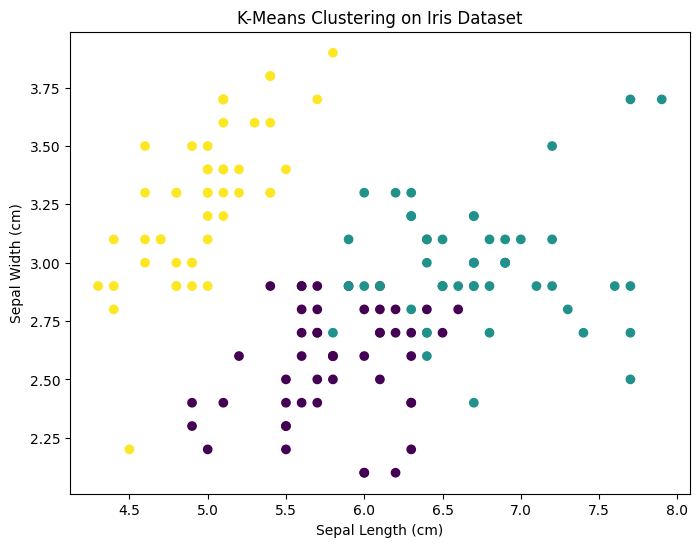

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
# Use the scaled numerical features for K-Means clustering
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

# Print cluster labels
print("\nK-Means Cluster Labels:")
print(df['KMeans_Cluster'].unique())

# Scatter plot Sepal Length vs Sepal Width
plt.figure(figsize=(8,6))
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)']-0.1, # Add a small offset to sepal width for better visibility if points overlap
            c=df['KMeans_Cluster'], cmap='viridis')
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("K-Means Clustering on Iris Dataset")
plt.show()

**Task 4: Apply Hierarchical Clustering**


Hierarchical Cluster Labels:
[1 0 2]


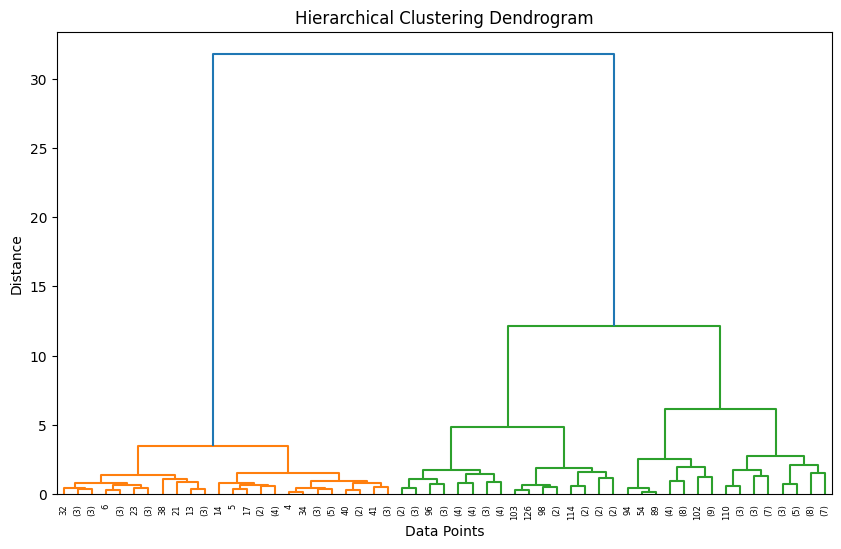

In [20]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
df['Hierarchical_Cluster'] = agg.fit_predict(df.iloc[:, 0:4])

# Print cluster labels
print("\nHierarchical Cluster Labels:")
print(df['Hierarchical_Cluster'].unique())

# Plot dendrogram
linked = linkage(df.iloc[:, 0:4], method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

**Task 5: Evaluate Clusters**

In [21]:
from sklearn.metrics import silhouette_score

# Silhouette Score for K-Means
kmeans_score = silhouette_score(df.iloc[:, 0:4], df['KMeans_Cluster'])
print("\nSilhouette Score for K-Means:", kmeans_score)

# Silhouette Score for Hierarchical
hierarchical_score = silhouette_score(df.iloc[:, 0:4], df['Hierarchical_Cluster'])
print("Silhouette Score for Hierarchical Clustering:", hierarchical_score)


Silhouette Score for K-Means: 0.5026740279777175
Silhouette Score for Hierarchical Clustering: 0.5583599607450273


**Task 6: Reflection**

In [25]:
print("\nReflection:")
print("The clusters reveal clear groupings in the Iris dataset, with some clusters more distinct in features like petal length and width.")
print("K-Means produced compact clusters, while hierarchical clustering shows a step-by-step merging of data points in the dendrogram.")
print("Both methods roughly correspond to the actual Iris species, although there is some overlap between similar species.")
print("Based on the silhouette scores—0.503 for K-Means and 0.558 for hierarchical clustering—hierarchical clustering had a slightly better separation.")
print("Overall, both techniques are useful for uncovering patterns, but hierarchical clustering gives a more detailed view of how data points relate to each other.")


Reflection:
The clusters reveal clear groupings in the Iris dataset, with some clusters more distinct in features like petal length and width.
K-Means produced compact clusters, while hierarchical clustering shows a step-by-step merging of data points in the dendrogram.
Both methods roughly correspond to the actual Iris species, although there is some overlap between similar species.
Based on the silhouette scores—0.503 for K-Means and 0.558 for hierarchical clustering—hierarchical clustering had a slightly better separation.
Overall, both techniques are useful for uncovering patterns, but hierarchical clustering gives a more detailed view of how data points relate to each other.
